**Step: 1 Importing All Required Libraries**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Dense, Flatten

In [ ]:
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


**Step: 2 Loading and Checking Datasets** 📋<br>
Here we use two datasets to link pollution causes with health effects, enabling accurate time-series prediction.

In [4]:
#Loading and checking the dataset.. I have 2 datasets (pollution for input and health for outpu)
pollution = pd.read_csv("pollution.csv")
health = pd.read_csv("health.csv")

print("Pollution Data:")
print(pollution.head())

print("\nHealth Data:")
print(health.head())

Pollution Data:
   Date  Month  Year  Holidays_Count  Days   PM2.5    PM10     NO2    SO2  \
0     1      1  2021               0     5  408.80  442.42  160.61  12.95   
1     2      1  2021               0     6  404.04  561.95   52.85   5.18   
2     3      1  2021               1     7  225.07  239.04  170.95  10.93   
3     4      1  2021               0     1   89.55  132.08  153.98  10.42   
4     5      1  2021               0     2   54.06   55.54  122.66   9.70   

     CO  Ozone  AQI  
0  2.77  43.19  462  
1  2.60  16.43  482  
2  1.40  44.29  263  
3  1.01  49.19  207  
4  0.64  48.88  149  

Health Data:
          city        date  aqi  pm2_5  pm10   no2    o3  temperature  \
0  Los Angeles  2020-01-01   65   34.0  52.7   2.2  38.5         33.5   
1      Beijing  2020-01-02  137   33.7  31.5  36.7  27.5         -1.6   
2       London  2020-01-03  266   43.0  59.6  30.4  57.3         36.4   
3  Mexico City  2020-01-04  293   33.7  37.9  12.3  42.7         -1.0   
4        D

In [5]:
#Checking the dataset Structure

print(pollution.info())
print(health.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1461 entries, 0 to 1460
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            1461 non-null   int64  
 1   Month           1461 non-null   int64  
 2   Year            1461 non-null   int64  
 3   Holidays_Count  1461 non-null   int64  
 4   Days            1461 non-null   int64  
 5   PM2.5           1461 non-null   float64
 6   PM10            1461 non-null   float64
 7   NO2             1461 non-null   float64
 8   SO2             1461 non-null   float64
 9   CO              1461 non-null   float64
 10  Ozone           1461 non-null   float64
 11  AQI             1461 non-null   int64  
dtypes: float64(6), int64(6)
memory usage: 137.1 KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88489 entries, 0 to 88488
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----

**Step 3: Clean + Align both datasets** 🧹<br>
So here we need to fix date formats
select useful columns
make both datasets compatible

In [6]:
#We need to make sure data formats are correct
pollution['Date'] = pd.to_datetime(
    pollution['Year'].astype(str) + "-" +
    pollution['Month'].astype(str) + "-" +
    pollution['Date'].astype(str)
)
health['date'] = pd.to_datetime(health['date'])

#We need to make same column name for merging
health.rename(columns={'date': 'Date'}, inplace=True)

#Sorting datasets by time here
pollution = pollution.sort_values('Date')
health = health.sort_values('Date')

#Keeping only the important columns
pollution = pollution[['Date', 'PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'Ozone', 'AQI']]
health = health[['Date', 'hospital_admissions']]

#Final step is to merge datasets
data = pd.merge(pollution, health, on="Date", how="inner")

#Let's check final results
print(data.head())
print(data.info())

        Date   PM2.5    PM10     NO2    SO2    CO  Ozone  AQI  \
0 2021-01-01  408.80  442.42  160.61  12.95  2.77  43.19  462   
1 2021-01-02  404.04  561.95   52.85   5.18  2.60  16.43  482   
2 2021-01-03  225.07  239.04  170.95  10.93  1.40  44.29  263   
3 2021-01-04   89.55  132.08  153.98  10.42  1.01  49.19  207   
4 2021-01-05   54.06   55.54  122.66   9.70  0.64  48.88  149   

   hospital_admissions  
0                    6  
1                    6  
2                    0  
3                   14  
4                   14  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1461 entries, 0 to 1460
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Date                 1461 non-null   datetime64[ns]
 1   PM2.5                1461 non-null   float64       
 2   PM10                 1461 non-null   float64       
 3   NO2                  1461 non-null   float64       
 4   SO2   

As of final structure it should look like this <br>
Date | PM2.5 | PM10 | NO2 | SO2 | CO | Ozone | AQI | hospital_admissions

So our model will learn that when pollution increases over time, hospital admissions also increase

**Step 4: Prepare data for Conv1D** ✅ <br>
For now our data is ready, but a neural network like Conv1D cannot learn from raw rows directly. It needs sequences (time windows).

In [7]:
# We separate input (X) and output (y)
features = ['PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'Ozone', 'AQI']

X_data = data[features]
y_data = data['hospital_admissions']

#Now we normalize data bcz Neural networks work better with scaled values.
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X_data)

#We now convert data into sliding windows. we use last 7 days to predict next day
def create_sequences(X, y, time_steps=7):
    Xs, ys = [], []

    for i in range(len(X) - time_steps):
        Xs.append(X[i:(i + time_steps)])
        ys.append(y[i + time_steps])

    return np.array(Xs), np.array(ys)

X_seq, y_seq = create_sequences(X_scaled, y_data.values, 7)

#Let us check new shape
print("X shape:", X_seq.shape)
print("y shape:", y_seq.shape)

X shape: (1454, 7, 7)
y shape: (1454,)


**Step: 5 Build and Train Conv1D Model** ✨<br>
Now we have sequences ready we build the deep learning model (conv1D).


In [9]:
#first we will split data we train on most data 80% and test on remaining 20%
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_seq, y_seq, test_size=0.2, shuffle=False
)

#building conv1D model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Dense, Flatten, Input

model = Sequential()

model.add(Input(shape=(7, 7)))
model.add(Conv1D(filters=64, kernel_size=2, activation='relu'))
model.add(Conv1D(filters=32, kernel_size=2, activation='relu'))
model.add(Flatten())

model.add(Dense(64, activation='relu'))
model.add(Dense(1))

#compiling model
model.compile(optimizer='adam', loss='mse')

#training model
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=32
)


Epoch 1/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 47.4395 - val_loss: 25.3696
Epoch 2/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 16.1967 - val_loss: 17.5905
Epoch 3/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 15.0936 - val_loss: 15.7322
Epoch 4/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 14.4045 - val_loss: 15.1179
Epoch 5/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 14.1765 - val_loss: 14.7572
Epoch 6/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 13.9760 - val_loss: 14.8182
Epoch 7/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 13.9434 - val_loss: 14.4150
Epoch 8/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 13.7933 - val_loss: 14.9413
Epoch 9/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 13.6472 - val_loss: 14.4460
Epoch 10/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 13.5815 - val_loss: 14.3625
Epoch 11/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 13.5115 - val_loss: 14.3206
Epoch 12/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 

**Step 6: Model Evaluation & Graphs** 📈 <br>
Visualize model performance and compare training vs validation loss

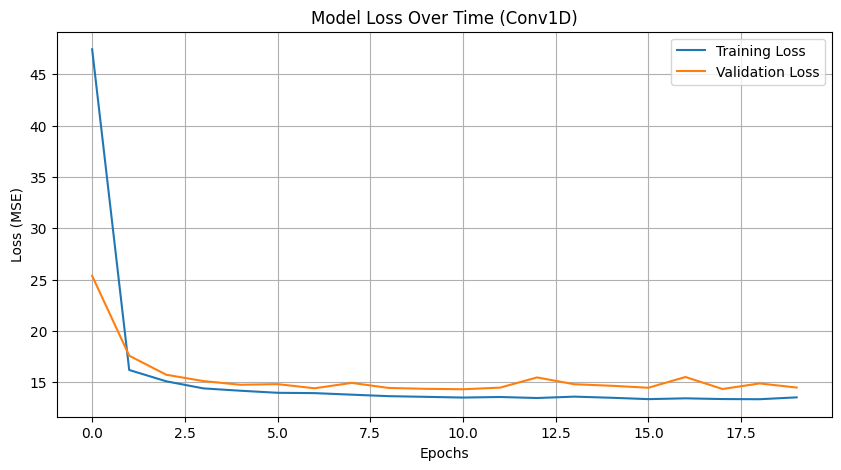

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


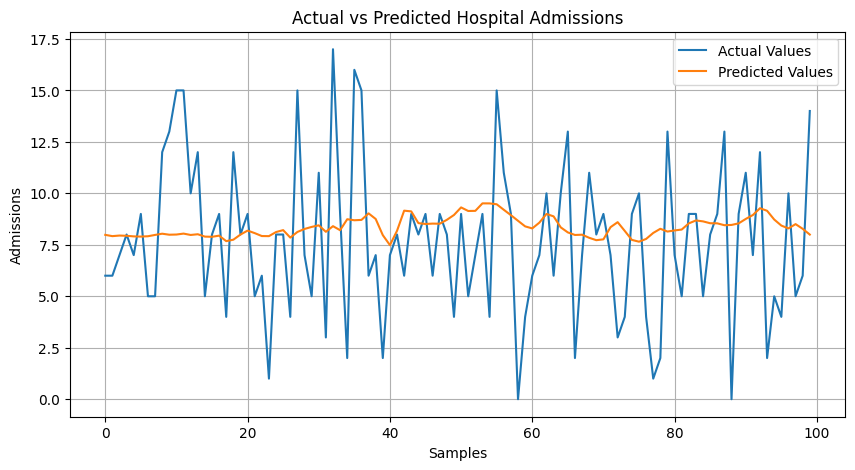

Mean Squared Error: 14.485859870910645


In [10]:
# Plot Training vs Validation Loss
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Model Loss Over Time (Conv1D)")
plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.grid(True)

plt.show()


#Let's check how good our model actually is
y_pred = model.predict(X_test)

#comparing actual vs prediction
plt.figure(figsize=(10,5))

plt.plot(y_test[:100], label='Actual Values')
plt.plot(y_pred[:100], label='Predicted Values')

plt.title("Actual vs Predicted Hospital Admissions")
plt.xlabel("Samples")
plt.ylabel("Admissions")
plt.legend()
plt.grid(True)

plt.show()

#Error checking
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

**Final Step: (bonus) Creating a User interface to test our model** ⚡

In [13]:
#Installing required libraries
!pip install streamlit
!pip install tensorflow
!pip install pandas numpy scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 59.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 76.4 MB/s eta 0:00:00


In [14]:
#Saving the trained model
model.save("pollution_model.h5")

In [15]:
#Saving the model to local file
from google.colab import files
files.download("pollution_model.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>